In [1]:
import numpy as np
from scipy.optimize import linprog

# configuration

width = 5               
height = 4              
gamma = 0.95            
solver_iters = 100      
actions = [(-1, 0), (1, 0), (0, 1), (0, -1), (0, 0)] # N, S, E, W, X
num_acts = 5
act_labels = ["N", "S", "E", "W", "X"]

B_slip_prob = 0.25      
step_cost = -0.05       
noise_floor = 0.05 # 5% uniform noise added to Nash to ensure full support

# visualization settings
grid_color = '#e0e0e0'
player_A_color = '#1f77b4' 
player_B_color = '#d62728' 
ball_color = '#ff7f0e'     

np.random.seed(1)

# game dynamics

def get_state_idx(ax, ay, bx, by, poss):
    return poss * (width*height)**2 + (ax*width+ay)*(width*height) + (bx*width+by)

def parse_state_idx(idx):
    poss = idx // ((width*height)**2)
    rem = idx % ((width*height)**2)
    a_idx = rem // (width*height)
    b_idx = rem % (width*height)
    ax, ay = a_idx // width, a_idx % width
    bx, by = b_idx // width, b_idx % width
    return ax, ay, bx, by, poss

def get_next_state_reward_done(ax, ay, bx, by, poss, act_a, act_b):
    dxa, dya = actions[act_a]; nax, nay = ax + dxa, ay + dya
    dxb, dyb = actions[act_b]; nbx, nby = bx + dxb, by + dyb
    
    # walls
    if nax < 0 or nax >= height or nay < 0 or nay >= width: nax, nay = ax, ay
    if nbx < 0 or nbx >= height or nby < 0 or nby >= width: nbx, nby = bx, by
    
    # goals
    if poss == 0 and nay == width-1: return (nax, nay, nbx, nby, poss), 100, True
    if poss == 1 and nby == 0:       return (nax, nay, nbx, nby, poss), -100, True
    
    next_poss = poss
    # collisions
    if (nax == bx and nay == by and nbx == ax and nby == ay) or (nax == nbx and nay == nby):
        nax, nay = ax, ay; nbx, nby = bx, by # bounce
        if np.random.rand() < 0.5: next_poss = 1 - poss
    elif nax == bx and nay == by and act_b == 4: nax, nay = ax, ay; next_poss = 1
    elif nbx == ax and nby == ay and act_a == 4: nbx, nby = bx, by; next_poss = 0
        
    return (nax, nay, nbx, nby, next_poss), step_cost, False

# solver (true Nash + smoothing)

pi_NE_A = np.ones((2 * (width * height) ** 2, num_acts)) / num_acts
pi_NE_B = np.ones((2 * (width * height) ** 2, num_acts)) / num_acts

def solve_matrix_game(Q_table):
    c = np.zeros(num_acts + 1); c[-1] = -1 
    A_eq = np.zeros((1, num_acts + 1)); A_eq[0, :num_acts] = 1; b_eq = [1.0]
    A_ub = np.hstack([ -Q_table.T, np.ones((num_acts, 1)) ]); b_ub = np.zeros(num_acts)
    bounds = [(0, 1) for _ in range(num_acts)] + [(None, None)]
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    if res.success:
        policy = res.x[:num_acts]
        policy[policy < 1e-8] = 0; policy /= np.sum(policy)
        return res.x[-1], policy
    return 0.0, np.ones(num_acts)/num_acts

def compute_equilibrium():
    global pi_NE_A, pi_NE_B
    print(f"Computing Nash Policies (Noise={noise_floor})...")
    V = np.zeros(2 * (width * height) ** 2)
    # heuristic init
    for idx in range(len(V)):
        ax, ay, bx, by, p = parse_state_idx(idx)
        V[idx] = (10.0 - ((width-1)-ay)) if p==0 else -(10.0 - by)

    for it in range(solver_iters):
        new_V = np.copy(V)
        delta = 0
        for idx in range(len(V)):
            ax, ay, bx, by, poss = parse_state_idx(idx)
            Q = np.zeros((num_acts, num_acts))
            
            for a in range(num_acts):
                for b in range(num_acts):
                    val_succ = 0; val_fail = 0
                    for is_fail in [False, True]:
                        eff_b = 4 if is_fail else b
                        ns, r_step, _ = get_next_state_reward_done(ax,ay,bx,by,poss,a,eff_b)
                        nax,nay,nbx,nby,nposs = ns
                        
                        term_r = r_step
                        if poss==0 and nay==width-1: term_r += 100
                        elif poss==1 and nby==0: term_r += -100
                        else:
                            if (nax==bx and nay==by and nbx==ax and nby==ay) or (nax==nbx and nay==nby):
                                term_r += gamma * (0.5*V[get_state_idx(ax,ay,bx,by,0)] + 0.5*V[get_state_idx(ax,ay,bx,by,1)])
                            elif nax==bx and nay==by and eff_b==4: term_r += gamma * V[get_state_idx(ax,ay,bx,by,1)]
                            elif nbx==ax and nby==ay and a==4: term_r += gamma * V[get_state_idx(ax,ay,bx,by,0)]
                            else: term_r += gamma * V[get_state_idx(nax,nay,nbx,nby,poss)]
                        
                        if is_fail: val_fail = term_r
                        else: val_succ = term_r
                    
                    Q[a,b] = (1.0-B_slip_prob)*val_succ + B_slip_prob*val_fail
            
            val, pol_a = solve_matrix_game(Q)
            _, pol_b = solve_matrix_game(-Q.T)
            new_V[idx] = val; pi_NE_A[idx] = pol_a; pi_NE_B[idx] = pol_b
            delta = max(delta, abs(V[idx]-val))
        V = new_V
        if delta < 1e-3: break
    
    # global smoothing
    # mix pure Nash with uniform noise to ensure full support
    # this prevents "infinite evidence" jumps 
    pi_NE_A = (1 - noise_floor) * pi_NE_A + noise_floor * (np.ones_like(pi_NE_A)/num_acts)
    pi_NE_B = (1 - noise_floor) * pi_NE_B + noise_floor * (np.ones_like(pi_NE_B)/num_acts)

# "afraid" policy generation 

pi_afraid = None

def generate_afraid_policy():
    """
    Afraid Policy: Reduces 'East' (2) mass and distributes to 'West' (3) or 'Wait' (4).
    Since Base is now smoothed, this acts as a 'Soft' deviation.
    """
    global pi_afraid
    pi_afraid = np.copy(pi_NE_A)
    
    for idx in range(len(pi_afraid)):
        p = pi_afraid[idx]
        east_prob = p[2]
        
        reduction = east_prob * 0.9
        
        p[2] -= reduction
        p[3] += reduction * 0.5 # West
        p[4] += reduction * 0.5 # Wait
        
        pi_afraid[idx] = p / np.sum(p)

# run
compute_equilibrium()
generate_afraid_policy()

Computing Nash Policies (Noise=0.05)...


Probabilities Format: [N, S, E, W, X]
Step 0:
  A (E): [0.01 0.01 0.96 0.01 0.01]
  B (W): [0.01 0.01 0.01 0.96 0.01] 
Step 1:
  A (E): [0.06 0.59 0.33 0.01 0.01]
  B (W): [0.01 0.05 0.01 0.47 0.45] **Slip!**
Step 2:
  A (N): [0.69 0.28 0.01 0.01 0.01]
  B (X): [0.01 0.01 0.01 0.01 0.96] 
Step 3:
  A (E): [0.01 0.01 0.96 0.01 0.01]
  B (N): [0.96 0.01 0.01 0.01 0.01] 
Step 4:
  A (E): [0.01 0.01 0.96 0.01 0.01]
  B (N): [0.96 0.01 0.01 0.01 0.01] 
Step 5:
  A (E): [0.01 0.01 0.96 0.01 0.01]
  B (N): [0.96 0.01 0.01 0.01 0.01] 
Step 6:
  A (S): [0.01 0.96 0.01 0.01 0.01]
  B (N): [0.96 0.01 0.01 0.01 0.01] 
Step 7:
  A (N): [0.96 0.01 0.01 0.01 0.01]
  B (S): [0.01 0.96 0.01 0.01 0.01] **Slip!**
Step 8:
  A (X): [0.01 0.01 0.01 0.01 0.96]
  B (X): [0.01 0.01 0.01 0.01 0.96] 
Step 9:
  A (X): [0.01 0.01 0.01 0.01 0.96]
  B (X): [0.01 0.01 0.01 0.01 0.96] 
Step 10:
  A (X): [0.01 0.01 0.01 0.01 0.96]
  B (X): [0.01 0.01 0.01 0.01 0.96] 
Step 11:
  A (X): [0.01 0.01 0.01 0.01 0.96]
  B (X)

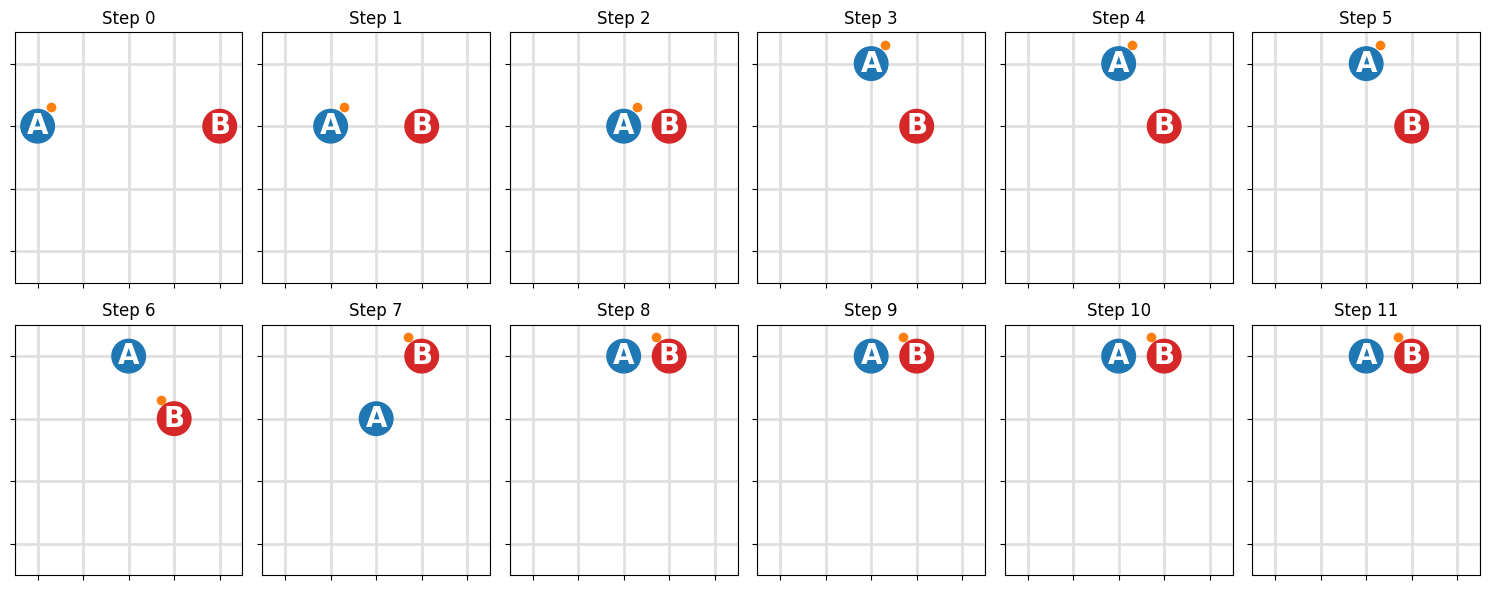

In [ ]:
import matplotlib.pyplot as plt
import csv

# visualization utils
def plot_film_strip(history, save_filename=None):
    n_steps = len(history)
    max_cols = 6
    n_rows = (n_steps + max_cols - 1) // max_cols
    n_cols = min(n_steps, max_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.5, n_rows*3))
    
    if n_steps == 1: 
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()
    
    for t, state in enumerate(history):
        ax_p, ay_p, bx_p, by_p, poss = state
        ax = axes_flat[t]
        
        ax.set_xlim(-0.5, width-0.5)
        ax.set_ylim(height-0.5, -0.5) 
        ax.set_xticks(np.arange(width))
        ax.set_yticks(np.arange(height))
        ax.grid(color=grid_color, linestyle='-', linewidth=2)
        ax.set_xticklabels([]); ax.set_yticklabels([])
        
        # goal areas
        ax.add_patch(plt.Rectangle((width-0.5, -0.5), 0.1, height, color=player_B_color, alpha=0.3))
        ax.add_patch(plt.Rectangle((-0.6, -0.5), 0.1, height, color=player_A_color, alpha=0.3))

        # players
        ax.text(ay_p, ax_p, 'A', ha='center', va='center', fontsize=20, color='white', fontweight='bold',
                bbox=dict(boxstyle="circle,pad=0.1", fc=player_A_color, ec=player_A_color))
        ax.text(by_p, bx_p, 'B', ha='center', va='center', fontsize=20, color='white', fontweight='bold',
                bbox=dict(boxstyle="circle,pad=0.1", fc=player_B_color, ec=player_B_color))
        
        # ball
        if poss == 0: bx_ball, by_ball = ax_p - 0.3, ay_p + 0.3
        else:         bx_ball, by_ball = bx_p - 0.3, by_p - 0.3
        ax.plot(by_ball, bx_ball, 'o', color=ball_color, markersize=8, markeredgecolor='white')
        
        # axes title
        ax.set_title(f"Step {t}", fontsize=12)
        
    for i in range(n_steps, len(axes_flat)):
        axes_flat[i].axis('off')
        
    plt.tight_layout()
    
    # save figure
    if save_filename:
        plt.savefig(f'plots/{save_filename}', format='pdf', bbox_inches='tight')
    
    return fig

def run_visual_episode(policy_a, save_csv_name=None):
    ax, ay = 1, 0
    bx, by = 1, width-1
    poss = 0
    history = []
    log_rows = [] 
    
    print(f"Probabilities Format: [N, S, E, W, X]")
    
    for step in range(12): 
        history.append((ax, ay, bx, by, poss))
        s_idx = get_state_idx(ax, ay, bx, by, poss)
        
        p_a = policy_a[s_idx]
        act_a = np.random.choice(num_acts, p=p_a)
        
        p_b = pi_NE_B[s_idx]
        act_b = np.random.choice(num_acts, p=p_b)
        
        real_act_b = act_b
        slip_txt = ""
        is_slip = False
        if np.random.rand() < B_slip_prob:
            real_act_b = 4
            if act_b != 4: 
                slip_txt = "**Slip!**"
                is_slip = True
            
        p_a_str = "[" + " ".join([f"{p:.2f}" for p in p_a]) + "]"
        p_b_str = "[" + " ".join([f"{p:.2f}" for p in p_b]) + "]"
        
        print(f"Step {step}:")
        print(f"  A ({act_labels[act_a]}): {p_a_str}")
        print(f"  B ({act_labels[act_b]}): {p_b_str} {slip_txt}")
        
        row = {
            "step": step,
            "ax": ax, "ay": ay, "bx": bx, "by": by, "poss": poss,
            "act_a": act_labels[act_a],
            "act_b": act_labels[act_b],
            "real_act_b": act_labels[real_act_b],
            "slip": is_slip,
            "p_a": p_a.tolist(),
            "p_b": p_b.tolist()
        }
        log_rows.append(row)
        
        next_s, r, done = get_next_state_reward_done(ax, ay, bx, by, poss, act_a, real_act_b)
        ax, ay, bx, by, poss = next_s
        
        if done:
            history.append((ax, ay, bx, by, poss))
            print(f"*** END: Reward {r} ***")
            log_rows.append({
                "step": step + 1,
                "ax": ax, "ay": ay, "bx": bx, "by": by, "poss": poss,
                "act_a": "END", "act_b": "END", "real_act_b": "END", "slip": False,
                "p_a": [], "p_b": []
            })
            break

    # save csv
    if save_csv_name:
        csv_path = f'results/{save_csv_name}'
        
        with open(csv_path, 'w', newline='') as f:
            writer = csv.writer(f)
            header = ["step", "ax", "ay", "bx", "by", "poss", "act_a", "act_b", "real_act_b", "slip"]
            header += [f"p_a_{l}" for l in act_labels]
            header += [f"p_b_{l}" for l in act_labels]
            
            writer.writerow(header)
            
            for r in log_rows:
                line = [r["step"], r["ax"], r["ay"], r["bx"], r["by"], r["poss"], 
                        r["act_a"], r["act_b"], r["real_act_b"], r["slip"]]
                if r["p_a"]:
                    line += r["p_a"] + r["p_b"]
                else:
                    line += [""] * (2 * num_acts)
                writer.writerow(line)
                            
    return history

hist_nash = run_visual_episode(pi_NE_A, save_csv_name="soccer/nash_history.csv")
fig = plot_film_strip(hist_nash, save_filename="soccer/nash_gameplay.pdf")
plt.show()

Probabilities Format: [N, S, E, W, X]
Step 0:
  A (X): [0.01 0.01 0.10 0.44 0.44]
  B (W): [0.01 0.01 0.01 0.96 0.01] 
Step 1:
  A (E): [0.01 0.01 0.10 0.44 0.44]
  B (X): [0.01 0.01 0.01 0.01 0.96] 
Step 2:
  A (N): [0.06 0.59 0.03 0.16 0.16]
  B (X): [0.01 0.05 0.01 0.47 0.45] 
Step 3:
  A (X): [0.01 0.01 0.10 0.44 0.44]
  B (E): [0.96 0.01 0.01 0.01 0.01] 
Step 4:
  A (X): [0.01 0.01 0.10 0.44 0.44]
  B (W): [0.01 0.01 0.01 0.96 0.01] 
Step 5:
  A (X): [0.01 0.01 0.10 0.44 0.44]
  B (N): [0.96 0.01 0.01 0.01 0.01] 
Step 6:
  A (X): [0.01 0.61 0.04 0.17 0.17]
  B (W): [0.01 0.32 0.01 0.65 0.01] 
Step 7:
  A (S): [0.01 0.62 0.04 0.17 0.17]
  B (N): [0.01 0.01 0.93 0.01 0.04] 
Step 8:
  A (W): [0.01 0.01 0.10 0.44 0.44]
  B (S): [0.01 0.96 0.01 0.01 0.01] 
Step 9:
  A (E): [0.01 0.49 0.05 0.23 0.23]
  B (W): [0.01 0.01 0.60 0.37 0.01] 
Step 10:
  A (S): [0.01 0.49 0.05 0.23 0.23]
  B (E): [0.01 0.01 0.60 0.37 0.01] 
Step 11:
  A (W): [0.01 0.01 0.10 0.44 0.44]
  B (S): [0.01 0.96 0.01 

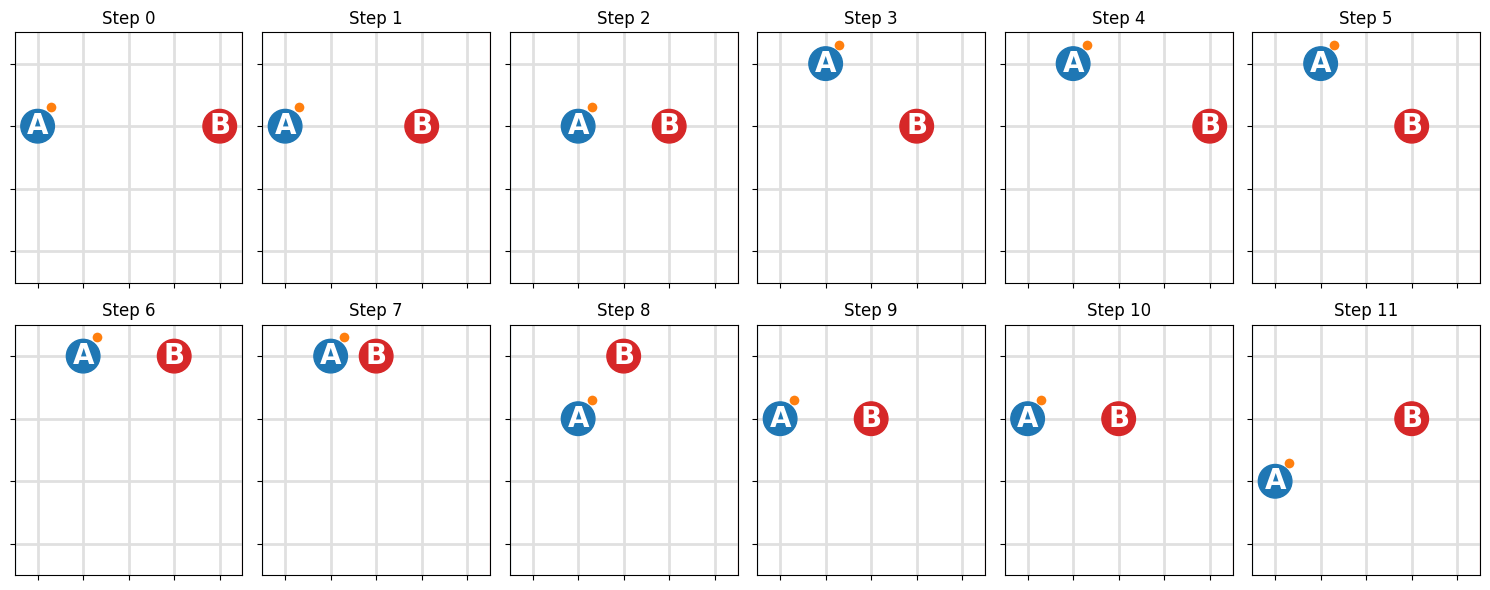

In [ ]:
# run episode using the global pi_afraid
hist_afraid = run_visual_episode(
    pi_afraid, 
    save_csv_name="soccer/afraid_history.csv"
)
fig = plot_film_strip(
    hist_afraid, 
    save_filename="soccer/afraid_gameplay.pdf"
)
plt.show()


Running Martingale Test (Eps 0.05 -> 0.5)
Eps=0.05 | Avg Time=1322.0 (+/- 103.7)
Eps=0.10 | Avg Time=374.0 (+/- 35.8)


C:\Users\etgauthi\AppData\Local\Temp\ipykernel_14976\3734779729.py:30: RuntimeWarning: overflow encountered in scalar multiply
  martingale *= lr


Eps=0.20 | Avg Time=118.9 (+/- 15.0)
Eps=0.30 | Avg Time=58.5 (+/- 9.4)
Eps=0.50 | Avg Time=16.4 (+/- 3.2)


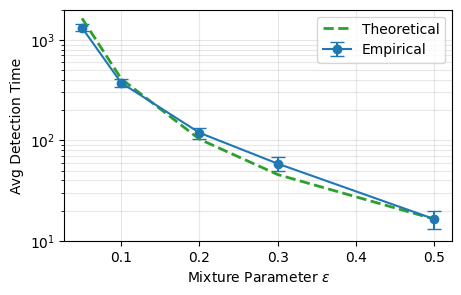

In [ ]:
np.random.seed(1)

def run_martingale_test(epsilon, threshold, max_steps=5000):
    ax, ay = 1, 0
    bx, by = 1, width-1
    poss = 0
    
    martingale = 1.0
    detected_step = None
    steps = 0
    
    while steps < max_steps:
        s_idx = get_state_idx(ax, ay, bx, by, poss)
        
        # get base policies
        pi_nash = pi_NE_A[s_idx]
        # pi_afraid = pi_afraid[s_idx]
        p_afraid = pi_afraid[s_idx]
        
        # construct true mixture strategy
        pi_true = (1 - epsilon) * pi_nash + epsilon * p_afraid
        
        # sample action
        act_a = np.random.choice(num_acts, p=pi_true)
        
        # detector
        prob_h0 = pi_nash[act_a]
        prob_h1 = (1 - epsilon) * pi_nash[act_a] + epsilon * p_afraid[act_a]
        lr = prob_h1 / prob_h0
        martingale *= lr
            
        # check threshold
        if detected_step is None and martingale > threshold:
            detected_step = steps + 1
            
        # opponent
        act_b = np.random.choice(num_acts, p=pi_NE_B[s_idx])
        real_act_b = act_b
        if np.random.rand() < B_slip_prob: real_act_b = 4
            
        next_s, _, done = get_next_state_reward_done(ax, ay, bx, by, poss, act_a, real_act_b)
        ax, ay, bx, by, poss = next_s
        steps += 1
        if done: 
             ax, ay = 1, 0; bx, by = 1, width-1; poss = 0
            
    if detected_step is None: detected_step = max_steps
    return detected_step

# parameters
threshold = 20.0 
epsilons = [0.05, 0.1, 0.2, 0.3, 0.5] 
n_trials = 150
max_steps = 25000

empirical_times = []
std_errs = []

print(f"\nRunning Martingale Test (Eps 0.05 -> 0.5)")

for eps in epsilons:
    detections = []
    for _ in range(n_trials):
        dt = run_martingale_test(eps, threshold, max_steps)
        detections.append(dt)
    
    mean_time = np.mean(detections)
    std_err = np.std(detections) / np.sqrt(n_trials)
    empirical_times.append(mean_time)
    std_errs.append(std_err)
    print(f"Eps={eps:.2f} | Avg Time={mean_time:.1f} (+/- {std_err:.1f})")

# theoretical scaling: T ~ K / epsilon^2
# Anchor to the last point
anchor_idx = -1 
K = empirical_times[anchor_idx] * (epsilons[anchor_idx]**2)
theoretical_times = [K / (e**2) for e in epsilons]

# plotting
plt.figure(figsize=(5, 3))
plt.errorbar(epsilons, empirical_times, yerr=std_errs, fmt='o-', label='Empirical', color='#1f77b4', capsize=5)
plt.plot(epsilons, theoretical_times, '--', label='Theoretical', color='#2ca02c', linewidth=2)

plt.ylim(10,2000)

plt.yscale('log')
plt.xscale('linear')
plt.xlabel(r'Mixture Parameter $\varepsilon$')
plt.ylabel('Avg Detection Time')
plt.grid(True, which='both', alpha=0.3)
plt.legend()

plt.savefig('plots/soccer/scaling.pdf')